# Save Final Model + Inference Pipeline

### Import Libraries

In [1]:
# Import libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

### Load Best Model Name from Comparison

In [2]:
# code

best_model_df = pd.read_csv(
    "../results/best_model.csv"
)

best_model_name = best_model_df[
    "Model"
][0]

print("Best model selected:")
print(best_model_name)

Best model selected:
MobileNet


### Map Model Name to File Path

In [3]:
# code

model_map = {

    "Custom CNN":
        "../models/custom_cnn_model.keras",

    "ResNet50":
        "../models/resnet50_model.keras",

    "MobileNet":
        "../models/mobilenet_model.keras",

    "EfficientNetB0":
        "../models/efficientnet_model.keras"

}

MODEL_PATH = model_map[
    best_model_name
]

print("Model path:")
print(MODEL_PATH)

Model path:
../models/mobilenet_model.keras


### Load the Best Model

In [4]:
# code

model = load_model(
    MODEL_PATH
)

print("Model loaded successfully")

Model loaded successfully


### Define Class Names

In [5]:
# code

class_names = [

    "bird",
    "drone"

]

print("Classes:", class_names)

Classes: ['bird', 'drone']


### Define Image Size

In [6]:
IMG_SIZE = (

    224,
    224

)

### Image Preprocessing Function

In [7]:
# code

def preprocess_image(
        img_path
):

    img = image.load_img(

        img_path,

        target_size=IMG_SIZE

    )

    img_array = image.img_to_array(
        img
    )

    img_array = img_array / 255.0

    img_array = np.expand_dims(

        img_array,

        axis=0

    )

    return img_array

### Define Test Image Path

In [8]:
# code

IMAGE_PATH = (
    "../data/test/bird/00296cddcbc1abbf_jpg.rf.775d2db93729689bb2208155e8a8aa09.jpg"
)

print("Testing image:")
print(IMAGE_PATH)

Testing image:
../data/test/bird/00296cddcbc1abbf_jpg.rf.775d2db93729689bb2208155e8a8aa09.jpg


### Predict Single Image

In [9]:
# code

img_array = preprocess_image(
    IMAGE_PATH
)

prediction = model.predict(
    img_array
)

predicted_class_index = np.argmax(
    prediction
)

confidence = np.max(
    prediction
)

predicted_class = class_names[
    predicted_class_index
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step


### Show Prediction Result

In [10]:
# code

print(
    "Predicted Class:",
    predicted_class
)

print(
    "Confidence:",
    round(
        confidence * 100,
        2
    ),
    "%"
)

Predicted Class: bird
Confidence: 100.0 %


### Display Image with Prediction

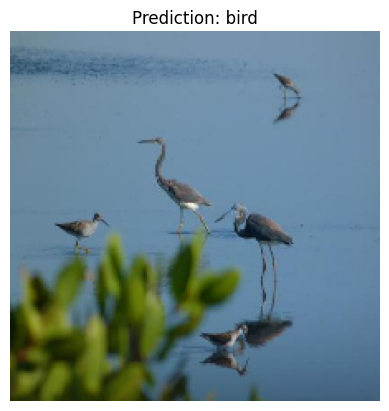

In [11]:
# code

img = image.load_img(
    IMAGE_PATH,
    target_size=IMG_SIZE
)

plt.imshow(
    img
)

plt.axis("off")

plt.title(

    f"Prediction: {predicted_class}"

)

plt.show()

### Batch Prediction Function

In [12]:
# code

def predict_folder(
        folder_path
):

    results = []

    for img_name in os.listdir(
            folder_path
    ):

        img_path = os.path.join(

            folder_path,
            img_name

        )

        try:

            img_array = preprocess_image(
                img_path
            )

            prediction = model.predict(
                img_array
            )

            class_index = np.argmax(
                prediction
            )

            confidence = np.max(
                prediction
            )

            results.append({

                "image":
                    img_name,

                "prediction":
                    class_names[
                        class_index
                    ],

                "confidence":
                    round(
                        confidence,
                        4
                    )

            })

        except Exception as e:

            print(
                "Skipping:",
                img_name
            )

    return pd.DataFrame(
        results
    )

### Run Batch Prediction

In [13]:
# code

folder_path = (
    "../data/test/bird"
)

predictions_df = predict_folder(
    folder_path
)

predictions_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

,image,prediction,confidence
0,00296cddcbc1abbf_jpg.rf.775d2db93729689bb22081...,bird,1.0000
1,002efdefb89bc9d5_jpg.rf.28ddbcc9003ffbd8938f60...,bird,0.9997
2,002efdefb89bc9d5_jpg.rf.2f41e54df9db32ab9891f1...,bird,0.9998
3,003236343c8ff7f2_jpg.rf.8149bd6905b692290fefb6...,bird,0.9999
4,003d95e6cd092860_jpg.rf.f46c270b0f35005fa2914d...,bird,0.9994
...,...,...,...
208,1e2465645cdd8c3e_jpg.rf.b2a1544f742350d2271da0...,bird,0.9999
209,1e4faacc3bb7a0fc_jpg.rf.abe4301269593e879a4529...,bird,0.9986
210,1e6049b37faae2bb_jpg.rf.7d21fa5454d04dba9b98c9...,bird,1.0000
211,1e645410d3a4aa16_jpg.rf.b13aa97157dd39a15a7345...,bird,1.0000


### Save Predictions to CSV

In [14]:
# code

predictions_df.to_csv(

    "../results/inference_results.csv",

    index=False

)

print(
    "Predictions saved successfully"
)

Predictions saved successfully


### Show Model Summary

In [15]:
# code

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,623,240 (13.82 MB)

 Trainable params: 131,458 (513.51 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

 Optimizer params: 262,918 (1.00 MB)